In [16]:
import os
# Ensure LaTeX is found (if using macOS MacTeX)
os.environ['PATH'] = os.environ['PATH'] + ':/Library/TeX/texbin'

import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
import matplotlib.patches as patches


# Set the global LaTeX export rules
mpl.rcParams.update({
    "pgf.texsystem": "pdflatex",
    "font.family": "serif",
    "text.usetex": True,           # ← change this
    "mathtext.fontset": "cm",
    "pgf.rcfonts": False,
    "axes.unicode_minus": False,
    "pgf.preamble": r"\usepackage{amsmath}",
    "text.latex.preamble": r"\usepackage{amsmath}",  # ← add this
})

def format_textbook_axes(ax, x_limits, y_limits, scale=1.0, x_label='$x$', y_label='$y$'):
    # Scale the font size relative to your base (14)
    fs = 14 * scale
    
    ax.spines['left'].set_position('zero')
    ax.spines['bottom'].set_position('zero')
    ax.spines['left'].set_color('gray')
    ax.spines['bottom'].set_color('gray')
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')
    ax.set_xticks([])
    ax.set_yticks([])

    # Scale the arrow markers proportionally
    ms = 6 * scale
    ax.plot((1), (0), ls="", marker=">", ms=ms, color="gray",
            transform=ax.get_yaxis_transform(), clip_on=False)
    ax.plot((0), (1), ls="", marker="^", ms=ms, color="gray",
            transform=ax.get_xaxis_transform(), clip_on=False)

    ax.set_xlim(x_limits)
    ax.set_ylim(y_limits)
    
    # Calculate the total span of the axes
    x_range = x_limits[1] - x_limits[0]
    y_range = y_limits[1] - y_limits[0]
    
    # x-label: placed right after the arrow tip, centered vertically on the y=0 line
    ax.text(x_limits[1] + 0.03 * x_range, 0, x_label, 
            fontsize=fs, fontstyle='italic', ha='left', va='center')
    
    # y-label: placed just above the arrow tip, centered horizontally on the x=0 line
    ax.text(0, y_limits[1] + 0.03 * y_range, y_label, 
            fontsize=fs, fontstyle='italic', ha='center', va='bottom')

def add_textbook_label(ax, x, y, text, scale=1.0, align='center'):
    # Scale both the font and the internal padding of the box
    fs = 14 * scale
    padding = 0.3 * scale
    
    bbox_props = dict(boxstyle=f"square,pad={padding}", fc="#D6EAF8", ec="none")
    
    ax.text(x, y, text, fontsize=fs, family='serif', 
            bbox=bbox_props, ha=align, va='center')


# ── Riemann / integral drawing helper ────────────────────────────────────────
# method: 'left' | 'right' | 'midpoint' | 'inscribed' | 'circumscribed'
#         | 'trapezoid'
# show_area: also fill the exact area under the curve
#
# Colors follow your existing palette; override via rect_color / area_color.
 
def draw_riemann(ax, f, a, b, n,
                 method='inscribed',
                 show_area=True,
                 rect_color='#C9D8F0',   # soft blue – matches your rectangles
                 rect_edge='#212121',
                 area_color='#F2D7D5',   # soft pink – matches your image
                 scale=1.0):
    """
    Draw Riemann-sum rectangles and/or the exact filled area for f on [a, b].
 
    Parameters
    ----------
    ax          : matplotlib Axes
    f           : callable, the function to integrate
    a, b        : float, integration limits
    n           : int, number of sub-intervals
    method      : sampling strategy for rectangle heights
                    'left'          – left endpoint
                    'right'         – right endpoint
                    'midpoint'      – midpoint
                    'inscribed'     – min of f on each sub-interval  (lower sum)
                    'circumscribed' – max of f on each sub-interval  (upper sum)
                    'trapezoid'     – draws trapezoids instead of rectangles
    show_area   : bool, shade the exact area under the curve
    rect_color  : fill colour for rectangles / trapezoids
    rect_edge   : edge colour
    area_color  : fill colour for the exact integral region
    scale       : matches your existing scale parameter (affects linewidths)
    """
    xs = np.linspace(a, b, n + 1)          # sub-interval endpoints
    dx = (b - a) / n
    lw = 1.0 * scale
 
    # ── 1. Exact area (drawn first so rectangles sit on top) ─────────────
    if show_area:
        x_fill = np.linspace(a, b, 500)
        ax.fill_between(x_fill, 0, f(x_fill),
                        color=area_color, alpha=0.55, zorder=1)
 
    # ── 2. Rectangles / trapezoids ────────────────────────────────────────
    for i in range(n):
        x_left  = xs[i]
        x_right = xs[i + 1]
        mid     = (x_left + x_right) / 2.0
 
        if method == 'trapezoid':
            # Draw a filled quadrilateral
            verts = [
                (x_left,  0),
                (x_left,  f(x_left)),
                (x_right, f(x_right)),
                (x_right, 0),
            ]
            trap = plt.Polygon(verts, closed=True,
                               facecolor=rect_color, edgecolor=rect_edge,
                               linewidth=lw, zorder=2)
            ax.add_patch(trap)
 
        else:
            # Determine rectangle height according to method
            if method == 'left':
                height = f(x_left)
            elif method == 'right':
                height = f(x_right)
            elif method == 'midpoint':
                height = f(mid)
            elif method == 'inscribed':
                # Sample f densely on sub-interval and take the minimum
                x_sub  = np.linspace(x_left, x_right, 50)
                height = float(np.min(f(x_sub)))
            elif method == 'circumscribed':
                x_sub  = np.linspace(x_left, x_right, 50)
                height = float(np.max(f(x_sub)))
            else:
                raise ValueError(f"Unknown method '{method}'. Choose from: "
                                 "left, right, midpoint, inscribed, "
                                 "circumscribed, trapezoid.")
 
            rect = patches.Rectangle(
                (x_left, 0), dx, height,
                linewidth=lw, edgecolor=rect_edge,
                facecolor=rect_color, zorder=2
            )
            ax.add_patch(rect)
 
    return ax

def add_textbook_ticks(ax, x_ticks=None, y_ticks=None, x_labels=None, y_labels=None, scale=1.0):
    """Adds cleanly formatted hash marks and LaTeX labels to the central axes."""
    fs = 12 * scale # Slightly smaller than the main 14pt font
    tick_length = 8 * scale
    
    if x_ticks is not None:
        ax.set_xticks(x_ticks)
        # Apply custom labels if provided, otherwise just use the numbers formatted as math
        if x_labels is not None:
            ax.set_xticklabels(x_labels, fontsize=fs)
        else:
            ax.set_xticklabels([f'${t}$' for t in x_ticks], fontsize=fs)
            
    if y_ticks is not None:
        ax.set_yticks(y_ticks)
        if y_labels is not None:
            ax.set_yticklabels(y_labels, fontsize=fs)
        else:
            ax.set_yticklabels([f'${t}$' for t in y_ticks], fontsize=fs)
            
    # Format the tick marks to look like traditional textbook hash marks crossing the line
    ax.tick_params(axis='both', direction='inout', length=tick_length, width=1*scale, colors='gray')
    
    # Optional: Hide the tick label for '0' if it overlaps the origin crosshair
    labels = ax.get_xticklabels() + ax.get_yticklabels()
    for label in labels:
        if label.get_text() == '$0$' or label.get_text() == '$0.0$':
            label.set_visible(False)

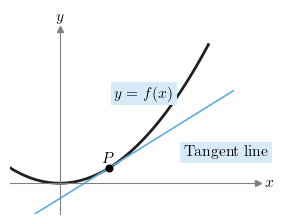

In [17]:
# tangent line problem graph

s = 0.8 

# 1. Create a blank canvas
fig, ax = plt.subplots(figsize=(4*s, 3*s))

# 2. Apply your custom textbook formatting (ADDED scale=s here)
format_textbook_axes(ax, x_limits=[-1, 4], y_limits=[-1, 5], scale=s)

# 3. Plot the math
x = np.linspace(-1, 3, 100)
y = x**2 / 2
x_tangent = np.linspace(-0.5, 3.5, 100)
y_tangent = 1 * (x_tangent - 1) + 0.5 

# Scale the line widths so they don't look overly chunky on a small graph
ax.plot(x, y, color='#212121', linewidth=2.5*s)
ax.plot(x_tangent, y_tangent, color='#5DADE2', linewidth=1.5*s)

# Add the point (SCALED the markersize and fontsize manually here)
ax.plot(1, 0.5, marker='o', color='black', markersize=6*s)
ax.text(0.85, 0.65, '$P$', fontsize=14*s, fontstyle='italic')

# 4. Use your new label function! (ADDED scale=s here)
add_textbook_label(ax, x=1.7, y=2.9, text='$y = f(x)$', scale=s)
add_textbook_label(ax, x=2.5, y=1.0, text='Tangent line', align='left', scale=s)

# 5. Save and export
fig.savefig("tangent-line-problem.pgf", backend="pgf", bbox_inches='tight')

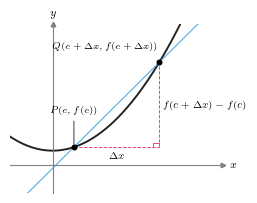

In [18]:
# Difference-quotient graph

s = 0.55

# 1. Create canvas and apply textbook axes (ADDED *s to figsize)
fig, ax = plt.subplots(figsize=(5*s, 4*s))
format_textbook_axes(ax, x_limits=[-1, 4], y_limits=[-1, 5], scale=s)

# 2. Define the math
def f(x): return x**2 / 2 + 0.5
c = 0.5
delta_x = 2.0
x_q = c + delta_x

# Plot the main curve (ADDED *s to linewidth)
x = np.linspace(-1, 3.5, 100)
ax.plot(x, f(x), color='#212121', linewidth=2.5*s)

# Plot the Secant Line (Blue) (ADDED *s to linewidth)
m_sec = (f(x_q) - f(c)) / delta_x
x_sec = np.linspace(-1, 4, 100)
y_sec = m_sec * (x_sec - c) + f(c)
ax.plot(x_sec, y_sec, color='#5DADE2', linewidth=1.5*s)

# 3. Add the structural dashed lines and right angle (Pink/Magenta)
pink_color = '#E13B8A' 
# Horizontal dashed line (ADDED *s to linewidth)
ax.plot([c, x_q], [f(c), f(c)], linestyle='--', color=pink_color, linewidth=1.2*s)
# Vertical dashed line (ADDED *s to linewidth)
ax.plot([x_q, x_q], [f(c), f(x_q)], linestyle='--', color=pink_color, linewidth=1.2*s)

# Right-angle box (ADDED *s to linewidth)
box_size = 0.15
ax.plot([x_q - box_size, x_q - box_size, x_q], 
        [f(c), f(c) + box_size, f(c) + box_size], 
        linestyle='-', color=pink_color, linewidth=1.2*s)

# 4. Points and Annotations
# Point P (ADDED *s to markersize, fontsize, and pointer lw)
ax.plot(c, f(c), marker='o', color='black', markersize=6*s, zorder=5)
ax.annotate('$P(c, f(c))$', xy=(c, f(c)), xytext=(c, f(c) + 1.2),
            arrowprops=dict(arrowstyle='-', color='black', lw=1*s), 
            fontsize=12*s, ha='center')

# Point Q (ADDED *s to markersize and fontsize)
ax.plot(x_q, f(x_q), marker='o', color='black', markersize=6*s, zorder=5)
ax.annotate('$Q(c+\\Delta x, f(c+\\Delta x))$', xy=(x_q, f(x_q)), xytext=(x_q, f(x_q) + 0.5),
            fontsize=12*s, ha='right')

# Labels for Delta x and Delta y (ADDED *s to fontsize)
ax.text(c + delta_x/2, f(c) - 0.4, '$\\Delta x$', fontsize=13*s, ha='center')
ax.text(x_q + 0.1, f(c) + (f(x_q)-f(c))/2, '$f(c+\\Delta x) - f(c)$', fontsize=13*s, va='center')

# 5. Save and export
fig.savefig("difference-quotient.pgf", backend="pgf", bbox_inches='tight')
plt.show()

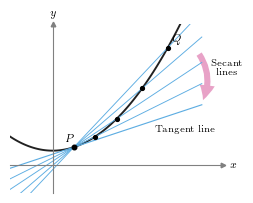

In [19]:
# Secant Limit Graph

import matplotlib.patches as patches

s = 0.55

# 1. Create canvas and apply textbook axes (ADDED *s to figsize)
fig, ax = plt.subplots(figsize=(5*s, 4*s))
format_textbook_axes(ax, x_limits=[-1, 4], y_limits=[-1, 5], scale=s)

# 2. Define the math
def f(x): return x**2 / 2 + 0.5
c = 0.5
x = np.linspace(-1, 3.5, 100)

# Plot the main curve (ADDED *s to linewidth)
ax.plot(x, f(x), color='#212121', linewidth=2.5*s)

# Plot the Tangent Line (Bottom blue line) (ADDED *s to linewidth)
m_tan = c 
y_tan = m_tan * (x - c) + f(c)
ax.plot(x, y_tan, color='#5DADE2', linewidth=1.5*s)

# 3. Draw multiple Secant lines using a loop
delta_x_values = [2.2, 1.6, 1.0, 0.5]

for dx in delta_x_values:
    x_q = c + dx
    m_sec = (f(x_q) - f(c)) / dx
    y_sec = m_sec * (x - c) + f(c)
    
    # Draw the secant line (ADDED *s to linewidth)
    ax.plot(x, y_sec, color='#5DADE2', linewidth=1.2*s)
    # Draw the point Q for this secant line (ADDED *s to markersize)
    ax.plot(x_q, f(x_q), marker='o', color='black', markersize=5*s, zorder=5)

# Point P (drawn last so it sits on top) (ADDED *s to markersize and fontsize)
ax.plot(c, f(c), marker='o', color='black', markersize=6*s, zorder=5)
ax.text(c - 0.2, f(c) + 0.2, '$P$', fontsize=14*s, fontstyle='italic')
ax.text(c + 2.2 + 0.1, f(c + 2.2) + 0.2, '$Q$', fontsize=14*s, fontstyle='italic')

# 4. Add labels (ADDED *s to fontsize)
ax.text(2.4, 1.2, 'Tangent line', fontsize=12*s, family='serif')
ax.text(4.1, 3.2, 'Secant\nlines', fontsize=12*s, family='serif', ha='center')

# 5. Create the large curved pink arrow (ADDED *s to mutation_scale)
curved_arrow = patches.FancyArrowPatch(
    (3.4, 4.0),    
    (3.5, 2.2),    
    connectionstyle="arc3,rad=-0.3", 
    color='#E8A2C7', 
    mutation_scale=40*s,  # This dictates the size of the arrowhead itself
    linewidth=0,
    zorder=1
)
ax.add_patch(curved_arrow)

# 6. Save and export
fig.savefig("secant-limit.pgf", backend="pgf", bbox_inches='tight')
plt.show()

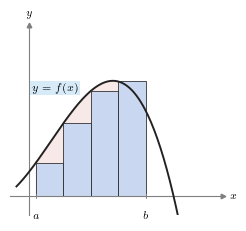

In [20]:
# ── Example: inscribed rectangles + exact area (matches your image) ──────────
if __name__ == '__main__':
 
    s = 0.55   # your scale factor
 
    # Define a function that looks like the one in the reference image:
    # rises steeply, has a gentle wave in the middle, then rises again.
    def f(x):
        return -0.7* x**3 + 0.7 * x**2 + 1.7 * x + .5
 
    a, b = 0.1, 1.8    # integration limits  → will be labelled a and b
    n    = 4           # number of rectangles
 
    fig, ax = plt.subplots(figsize=(5 * s, 4.5 * s))
    format_textbook_axes(ax, x_limits=[-0.3, 3],
                             y_limits=[-0.4, 3.5], scale=s)
 
    # Draw rectangles + shaded area
    draw_riemann(ax, f, a, b, n,
                 method='left',
                 show_area=True, # shows the exact area under the curve
                 scale=s)
 
    # Plot the curve on top
    x_curve = np.linspace(-0.2, 6.2, 400)
    ax.plot(x_curve, f(x_curve), color='#212121', linewidth=2.5 * s, zorder=3)
 
    # a and b tick marks + labels
    tick_h = 0.08 * s
    for val, lbl in [(a, '$a$'), (b, '$b$')]:
        ax.plot([val, val], [-tick_h, tick_h], color='gray',
                linewidth=1.2 * s, zorder=4)
        ax.text(val, -0.32, lbl, fontsize=14 * s,
                fontstyle='italic', ha='center', va='top')
 
    # Curve label
    add_textbook_label(ax, x=0.4, y=2.2, text='$y = f(x)$', scale=s)
 
    fig.savefig("area-problem-n4.pgf", backend="pgf", bbox_inches='tight')
    plt.show()

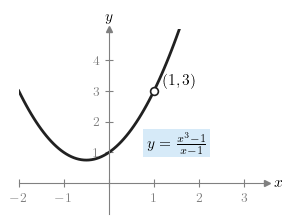

In [21]:
# hole in (x**3 - 1) / (x - 1)

s = 0.8 

# 1. Create a blank canvas
fig, ax = plt.subplots(figsize=(4*s, 3*s))

# 2. Apply textbook formatting 
# Extended x_limits to 3.5 so the axis is long enough to hold the '3' tick mark
format_textbook_axes(ax, x_limits=[-2, 3.5], y_limits=[-1, 5], scale=s)

# Removed the '4' tick, as the curve exits the top of the graph rapidly anyway
add_textbook_ticks(ax, x_ticks=[-2, -1, 0, 1, 2, 3], y_ticks=[1, 2, 3, 4], scale=s)

# 3. Plot the math
x = np.linspace(-2, 3.5, 100)
y = x**2 + x + 1 

# Draw the main line 
ax.plot(x, y, color='#212121', linewidth=2.5*s, zorder=2)

# Add the OPEN CIRCLE (hole)
ax.plot(1, 3, marker='o', markerfacecolor='white', markeredgecolor='#212121', 
        markersize=7*s, markeredgewidth=1.5*s, zorder=5)
        
ax.text(1.2, 3.2, '$(1, 3)$', fontsize=14*s, fontstyle='italic')

# 4. Use your label function
add_textbook_label(ax, x=1.5, y=1.3, text='$y = \\frac{x^3 - 1}{x - 1}$', scale=s)

# 5. Save and export
fig.savefig("hole1.pgf", backend="pgf", bbox_inches='tight')

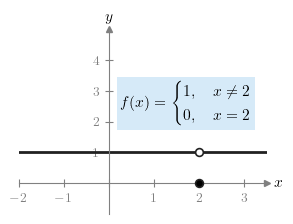

In [22]:
# hole in horizontal line

s = 0.8 

# 1. Create a blank canvas
fig, ax = plt.subplots(figsize=(4*s, 3*s))

# 2. Apply textbook formatting 
# Extended x_limits to 3.5 so the axis is long enough to hold the '3' tick mark
format_textbook_axes(ax, x_limits=[-2, 3.5], y_limits=[-1, 5], scale=s)

# Removed the '4' tick, as the curve exits the top of the graph rapidly anyway
add_textbook_ticks(ax, x_ticks=[-2, -1, 0, 1, 2, 3], y_ticks=[1, 2, 3, 4], scale=s)

# 3. Plot the math
x = np.linspace(-2, 3.5, 100)
y = np.ones_like(x)
y[np.isclose(x, 2)] = np.nan

# Draw the main line 
ax.plot(x, y, color='#212121', linewidth=2.5*s, zorder=2)

# Add the OPEN CIRCLE (hole)
ax.plot(2, 1, marker='o', markerfacecolor='white', markeredgecolor='#212121', 
        markersize=7*s, markeredgewidth=1.5*s, zorder=5)
        

# Add the CLOSED CIRCLE (hole)
ax.plot(2, 0, marker='o', markerfacecolor='black', markeredgecolor='#212121', 
        markersize=7*s, markeredgewidth=1.5*s, zorder=5)


# 4. Use your label function
text = r'$f(x) = \begin{cases} 1, \quad x \neq 2 \\ 0, \quad x = 2 \end{cases}$'
add_textbook_label(ax, x=1.7, y=2.6, text=text, scale=s)

# 5. Save and export
fig.savefig("hole2.pgf", backend="pgf", bbox_inches='tight')